🏏 Cricket Player Performance Analysis

<>:76: SyntaxWarning: invalid escape sequence '\*'
<>:76: SyntaxWarning: invalid escape sequence '\*'
/tmp/ipykernel_2471/2169980521.py:76: SyntaxWarning: invalid escape sequence '\*'
  df['Was_Not_Out'] = df['Highest_Score'].astype(str).str.contains('\*')
/tmp/ipykernel_2471/2169980521.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BF'].fillna(df['BF'].mean(), inplace=True)
/tmp/ipykernel_2471/2169980521.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment u

Dataset Loaded Successfully
The information of the players is : 
             Player       Span  Mat  Inns  NO  Runs    HS    Ave     BF  \
0  DG Bradman (AUS)  1928-1948   52    80  10  6996   334  99.94  9800+   
1    HC Brook (ENG)  2022-2023   12    20   1  1181   186  62.15   1287   
2    AC Voges (AUS)  2015-2016   20    31   7  1485  269*  61.87   2667   
3   RG Pollock (SA)  1963-1970   23    41   4  2256   274  60.97  1707+   
4   GA Headley (WI)  1930-1954   22    40   4  2190  270*  60.83   416+   

      SR  100  50  0   4s  6s  
0  58.60   29  13  7  626   6  
1  91.76    4   7  1  141  23  
2  55.68    5   4  2  186   5  
3  54.48    7  11  1  246  11  
4  56.00   10   5  2  104   1  
The structure of the data is : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  68 non-null     object 
 1   Span    68 non-null     object 
 2   Mat 

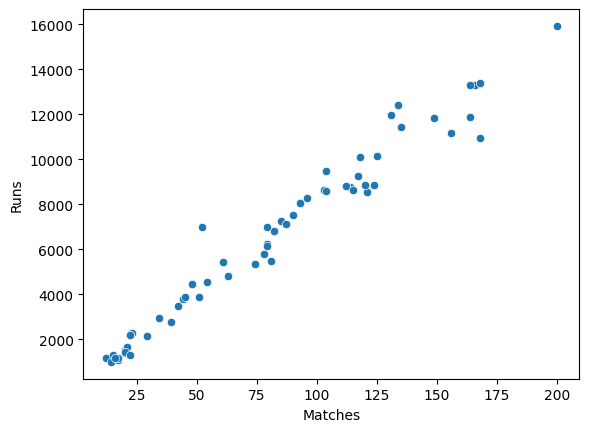

Does the players with more innings always scored more runs :
         Innings     Runs
Innings  1.00000  0.98754
Runs     0.98754  1.00000


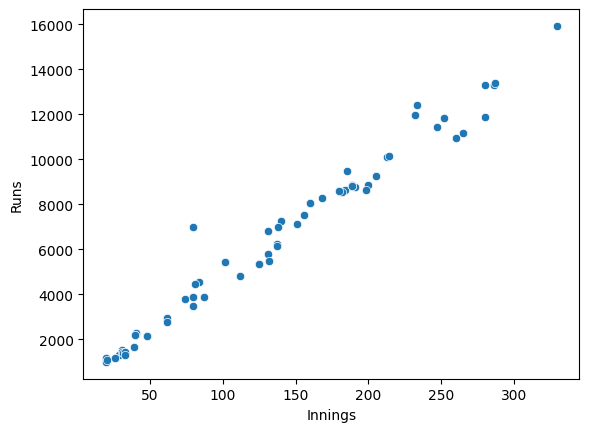

Comparing strike rate with batting average :
              Average  Strike_Rate
Average      1.000000     0.162908
Strike_Rate  0.162908     1.000000


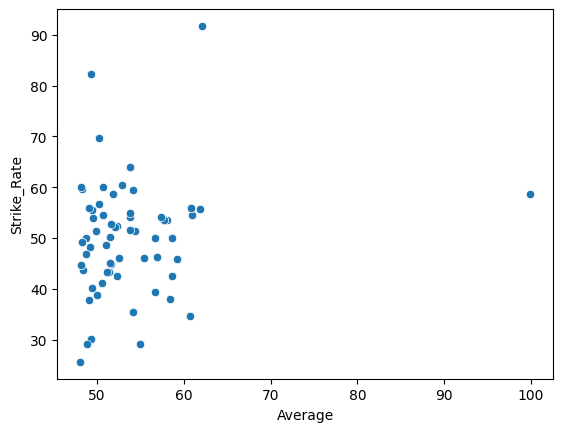

The country that has the most players in the dataset is :
Country
AUS        18
ENG        14
WI         10
SA          5
IND         5
PAK         4
SL          3
NZ          2
ICC/SA      2
ICC/IND     2
ICC/WI      1
ZIM         1
ICC/PAK     1
Name: count, dtype: int64
The country that has the highest average player performance is :
Country
WI         55.779000
ENG        55.092143
NZ         54.065000
AUS        53.969444
ICC/WI     52.880000
SA         52.680000
SL         52.000000
ICC/SA     51.810000
IND        51.572000
ZIM        51.540000
PAK        51.517500
ICC/IND    50.825000
ICC/PAK    49.600000
Name: Average, dtype: float64
The country that plays more aggressive cricket is :
Country
AUS        113168
ENG         61231
ICC/IND     21874
ICC/PAK      8830
ICC/SA      22554
ICC/WI      11953
IND         44707
NZ           9715
PAK         27641
SA          19121
SL          29676
WI          54265
ZIM          4794
Name: Runs, dtype: int64
Does longer career length lead 

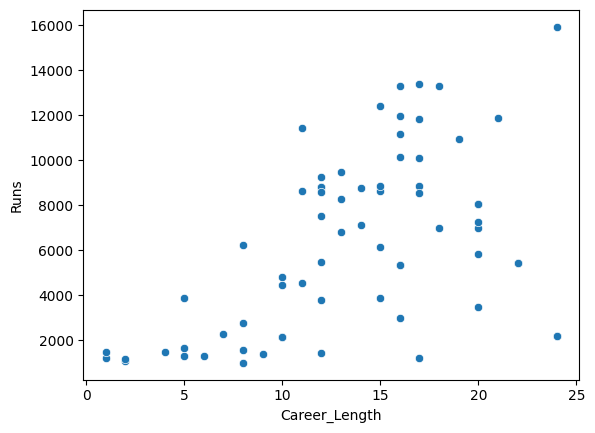

The players with long careers but low performance :
    Player_Name  Career_Length  Runs
4    GA Headley             24  2190
5    GA Headley             24  2190
15     JB Hobbs             22  5410
16     JB Hobbs             22  5410
25    AD Nourse             16  2960
46  DCS Compton             20  5807
49  FMM Worrell             15  3860
52      CP Mead             17  1185
57   B Mitchell             20  3471
60    RN Harvey             15  6149
61   KD Walters             16  5357
62   KD Walters             16  5357
The player with highest 100's :
     Player_Name  100
26  SR Tendulkar   51
The player with highest 50's :
     Player_Name  50
26  SR Tendulkar  68
The ratio of 100's to matches is :
   Player_Name  100  Matches  100s_per_match
0   DG Bradman   29       52        0.557692
4   GA Headley   10       22        0.454545
5   GA Headley   10       22        0.454545
17  CL Walcott   15       44        0.340909
1     HC Brook    4       12        0.333333
The players w

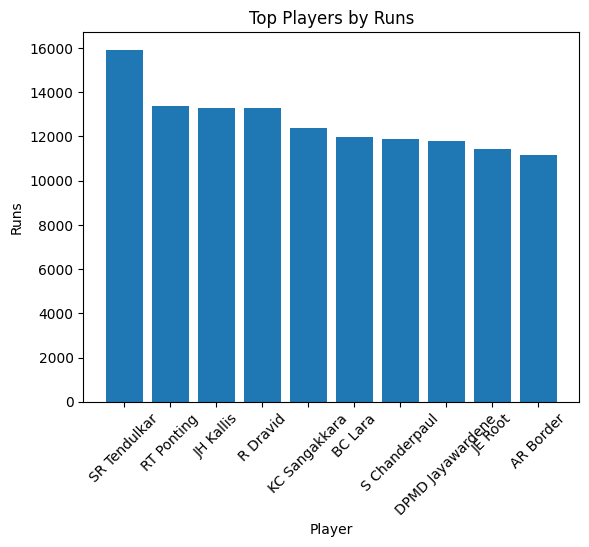

Scatter plot of Average vs Strike Rate : 


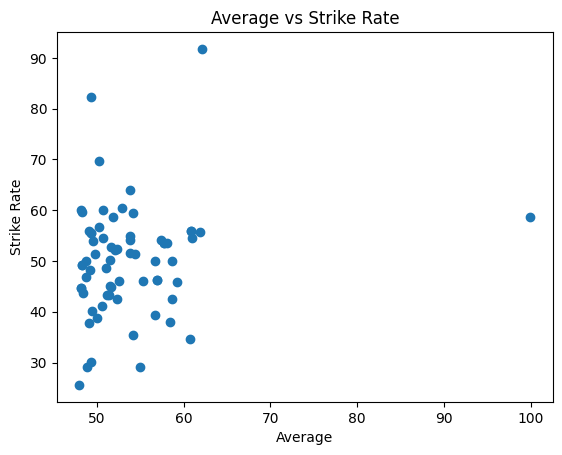

Heatmap of Correlation matrix : 


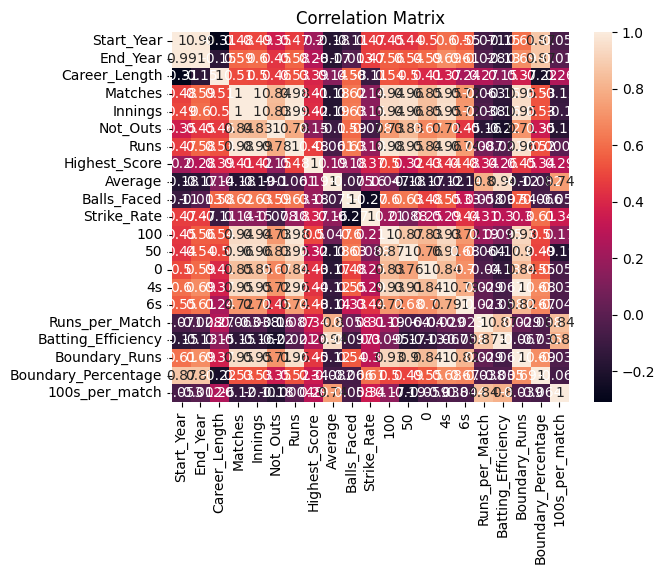

Boxplot of detected outliers : 


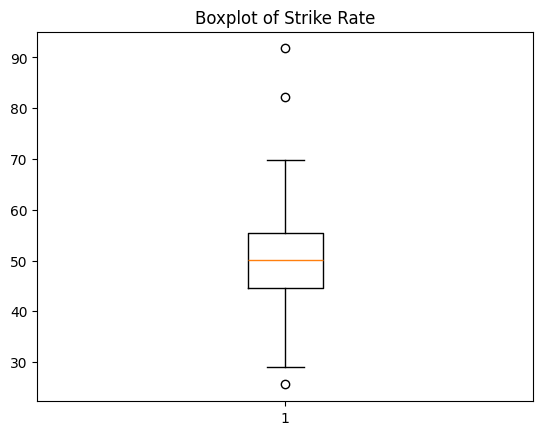

Pie chart of Country Distribution : 


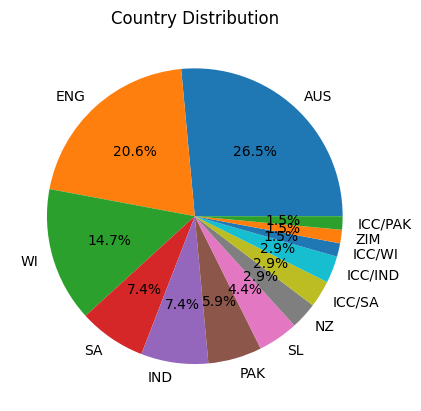


Cleaned dataset saved successfully!


In [2]:
# ===================== 1.Import Libraries =====================
# Explanation : This section performs importing required libraries that we use for Cricket Player Performance Analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 2.Load Dataset  =================
# Explanation : This section performs loading the dataset that contains required information to do analysis.
def Cricket_player_performance_analysis(file_path):
    try:
        df = pd.read_csv(file_path)
        print("Dataset Loaded Successfully")  # if file is found
    except FileNotFoundError:
        print("File Not Found")  # if filenotfound error occurs
        return None
    except Exception as e:
        print("Error:", e)        # if any other error occurs rather than filenotfound error
        return None

    # ================= 3.Check Data  =================
    # Explanation : Checking the data whether it is loaded or not.
    print("The information of the players is : ")
    print(df.head())
    print("The structure of the data is : ")
    print(df.info())
    print("The column names are : ")
    print(df.columns)

    # ================= BASIC CLEANING =================

    # ================= 1.Check Missing Values =================
    # Explanation : Checking the data whether is there any missing values in the data and to confirm how many are missing.
    print("Checking Missing Values :")
    print(df.isnull().sum())

    # ================= 2.Convert Datatype =================
    # Explanation : converting the "BF" column datatype to numeric... Bcz currently "BF" is an object so it might contain text or symbols

    df['BF'] = pd.to_numeric(df['BF'], errors='coerce')

    # ================= 3.Handle Missing Values =================
    # Explanation : Filling missing values that are missing... If we ignore missing values calculations become wrong and graph becomes misleading.

    df['BF'].fillna(df['BF'].mean(), inplace=True)
    df['SR'].fillna(df['SR'].mean(), inplace=True)

    print("Checking missing values again")
    print(df.isnull().sum())

    # ================= 4.Checking for incorrect daatatypes =================
    # Explanation : checking if any datatyes are incorrect... If any datatype is incorrect then fix it.
    print("Checking struture of the data :")
    print(df.info())

    # ================= 5.Renaming columns =================
    # Explanation : Renaming column names helps to better readability,understandable
    df.rename(columns={
        'Mat': 'Matches',
        'Inns': 'Innings',
        'NO': 'Not_Outs',
        'HS': 'Highest_Score',
        'Ave': 'Average',
        'SR': 'Strike_Rate',
        'BF': 'Balls_Faced'
    }, inplace=True)

    # Checking column names are changed or not
    print("The column names are : ")
    print(df.columns)

    # ================= String & Format Cleaning =================
    # ================= 1.Create a new column to indicate Not Out innings   =================
    # Explanation : We will Create a new column to indicate Not Out innings seperately.

    df['Was_Not_Out'] = df['Highest_Score'].astype(str).str.contains('\*')

    # ================= 2.Clean the HS column by removing special characters (*)    =================
    # Explanation : I have cleaned the Highest Score column by removing special characters and created a new feature to identify not-out innings.

    df['Highest_Score'] = df['Highest_Score'].astype(str).str.replace('*', '', regex=False)    # In regex, * is NOT a normal character..It is a special symbol meaning: repeat the previous character and to treat * as normal character we use regex=False..
    df['Highest_Score'] = pd.to_numeric(df['Highest_Score'], errors='coerce')    # I used errors='coerce' to handle invalid data gracefully by converting non-numeric values into NaN, ensuring the pipeline does not break.

    # ================= 3.Extract Player Name and Country from Player column     =================
    # Explanation : I have used errors='coerce' to handle invalid data gracefully by converting non-numeric values into NaN, ensuring the pipeline does not break.

    df['Player_Name'] = df['Player'].str.split('(').str[0].str.strip()
    df['Country'] = df['Player'].str.split('(').str[1].str.replace(')', '', regex=False)

    # ================= Column Transformation =================

    # ================= 1.Split Span into: Start Year & End Year   =================
    # Explanation : I transformed the Span column into Start and End years.

    df[['Start_Year', 'End_Year']] = df['Span'].str.split('-',n=1, expand=True)

    # ================= 2.Convert extracted years into integer format    =================
    # Explanation : I have converted the transformed Start and End years to numeric type bcz the span column is of object datatype.

    df['Start_Year'] = pd.to_numeric(df['Start_Year'], errors='coerce')
    df['End_Year'] = pd.to_numeric(df['End_Year'], errors='coerce')

    # =================  3.Create a new column: Career_Length = End Year - Start Year =================
    # Explanation : I have derived Career Length to analyze player longevity.

    df['Career_Length'] = df['End_Year'] - df['Start_Year']

    # =================  Structural Cleaning   =================
    # =================  1.Identify and remove duplicate rows ,Drop unnecessary or redundant columns and Reorder columns for better readability    =================
    # Explanation : Keep only required columns and arrange them neatly

    df = df[['Player_Name', 'Country', 'Start_Year',
          'End_Year', 'Career_Length','Matches', 'Innings', 'Not_Outs', 'Runs',
          'Highest_Score', 'Average', 'Balls_Faced', 'Strike_Rate', '100', '50',
          '0', '4s', '6s', 'Was_Not_Out']]

    # =================  Feature Engineering   =================

    # Explanation : I have engineered new features such as runs per match, batting efficiency, and boundary percentage to better capture player performance and playing style.

    # =================  1. Create Runs_per_Match   =================

    df['Runs_per_Match'] = df['Runs'] / df['Matches']

    # =================  2.Create Batting_Efficiency = Runs / Inns    =================

    df['Batting_Efficiency'] = np.where(
        df['Innings'] != 0,        # condition
        df['Runs'] / df['Innings'], # if true
        np.nan                      # if false
    )
    # I used np.where() to apply conditional logic, ensuring division is performed only when innings is non-zero, otherwise assigning NaN to maintain data integrity. Bcz If innings is valid → calculate,Else → leave it blank (NaN)

    # =================  3.Calculate Boundary_Runs = (4s × 4) + (6s × 6)    =================

    df['Boundary_Runs'] = (df['4s'] * 4) + (df['6s'] * 6)

    # ================= 4.Create Boundary_Percentage    =================

    df['Boundary_Percentage'] = df['Boundary_Runs'] / df['Runs']

    # =================  5.Creating runs difference and ranks   =================

    # Explanation : Creating runs difference between the players and ranking them based upon the runs made by the player helpful for better analysis and to identify the best players easily.I calculated rank-wise performance gaps using the diff() function to understand how closely players compete with each other.

    df_sorted = df.sort_values(by='Runs', ascending=False)
    df_sorted['Run_Difference'] = df_sorted['Runs'].diff().abs()
    df_sorted['Rank'] = range(1, len(df_sorted) + 1)

    print("Checking the results of runs_difference and ranking players : ")
    print(df_sorted[['Rank','Player_Name','Country', 'Runs', 'Run_Difference']].head(5))

    # =================  Player Performance   =================

    # =================  1.Who has the highest batting average?    =================

    # Explanation : I sorted players by total runs to identify top performers.sort_values() → sorts data ,ascending=False → highest first , .head(5) → top 5 players
    print("The player having the highest batting average is :")
    print(df.sort_values(by='Average', ascending=False)[['Player_Name', 'Average']].head(1))

    # =================  2.Who scored the most total runs?    =================

    # Explanation : The player who has Highest average is consistent player.
    print("The player scored the most total runs is :")
    print(df.sort_values(by='Runs', ascending=False)[['Player_Name','Runs']].head(1))

    # =================  3.Find the top 10 players based on runs    =================
    print("The top 10 players scored the most total runs is :")
    print(df.sort_values(by='Runs', ascending=False)[['Player_Name','Runs']].head(10))

    # ================= 4.Find the top 10 players based on strike rate    =================
    print("The top 10 players having more strike rate are :")
    print(df.sort_values(by='Strike_Rate', ascending=False)[['Player_Name', 'Strike_Rate']].head(10))

    # =================  5.Identify players with both high average and high strike rate =================
    # Explanation : First we use average values of both avg and sr to analyse high-performing players by filtering those who balances both consistency and aggression.

    avg_mean = df['Average'].mean()
    sr_mean = df['Strike_Rate'].mean()

    top_players = df[
        (df['Average'] > avg_mean) &
        (df['Strike_Rate'] > sr_mean)
    ]
    print("The top players with both high average and high strike rate are : ")
    print(top_players[['Player_Name','Country', 'Average', 'Strike_Rate']])

    # =================  Comparative Analysis =================
    # =================  1.Is there a relationship between matches played and runs scored?    =================
    # Explanation : correlation gives a value b/w +1 to -1...+1 ->	Strong positive relation ,0->	No relation,-1->	Negative relation... Here we use correlation to check whether there is a relationship b/w runs and matches.If value is close to +1: Players who play more matches tend to score more runs.
    print("The relationship between matches played and runs scored is :")
    print(df[['Matches', 'Runs']].corr())

    sns.scatterplot(x='Matches', y='Runs', data=df)
    plt.show()

    # =================  2.Do players with more innings always score more runs? =================
    # Explanation : Calculating Innings is Usually stronger than matches ,Players with more innings tend to score more runs.
    print("Does the players with more innings always scored more runs :")
    print(df[['Innings', 'Runs']].corr())

    sns.scatterplot(x='Innings', y='Runs', data=df)
    plt.show()

    # =================  3.Compare strike rate vs batting average   =================
    print("Comparing strike rate with batting average :")
    print(df[['Average', 'Strike_Rate']].corr())

    sns.scatterplot(x='Average', y='Strike_Rate', data=df)
    plt.show()

    # Explanation : While matches and innings showcorrelation with runs, comparing average and strike will show relationship, indicating different playing styles.

    # =================  Country-Based Insights   =================
    # =================  1.Which country has the most players in the dataset? =================
    # Explanation : It tells which country has the most players in the dataset.
    print("The country that has the most players in the dataset is :")
    print(df['Country'].value_counts())

    # ================= 2.Which country has the highest average player performance? =================
    # Explanation : It tells which country has the highest average player performance.
    print("The country that has the highest average player performance is :")
    print(df.groupby('Country')['Average'].mean().sort_values(ascending=False))

    # =================  3.Compare total runs contributed by each country   =================
    # Explanation : It tells which country plays more aggressive cricket.
    print("The country that plays more aggressive cricket is :")
    print(df.groupby('Country')['Runs'].sum())

    # =================  Career Analysis   =================

    # =================  1.Does longer career length lead to higher total runs? =================
    # Explanation : If correlation is High → longer career = more runs ,Low → no strong relation
    print("Does longer career length lead to higher total runs :")
    print(df[['Career_Length', 'Runs']].corr())

    print(df.sort_values(by='Career_Length', ascending=False)[['Player_Name', 'Career_Length', 'Runs']].head(5))

    sns.scatterplot(x='Career_Length', y='Runs', data=df)
    plt.show()

    # =================  2.Identify players with long careers but low performance   =================
    # Explanation : I identified players with long careers but relatively low performance by comparing career length with average runs. This highlights players who had longevity but lower impact.

    career_mean = df['Career_Length'].mean()
    runs_mean = df['Runs'].mean()

    long_low_players = df[
        (df['Career_Length'] > career_mean).sort_values(ascending=False) &
        (df['Runs'] < runs_mean).sort_values(ascending=False)
    ]
    print("The players with long careers but low performance :")
    print(long_low_players[['Player_Name', 'Career_Length', 'Runs']])

    # =================  Consistency & Milestones   =================
    # =================  1.Who has the most centuries (100s)?    =================
    # Explanation : It gives top player with highest 100's
    print("The player with highest 100's :")
    print(df.sort_values(by='100', ascending=False)[['Player_Name', '100']].head(1))

    # =================  2.Who has the most half-centuries (50s)?   =================
    # Explanation : It gives top player with highest 50's
    print("The player with highest 50's :")
    print(df.sort_values(by='50', ascending=False)[['Player_Name', '50']].head(1))

    # =================  3.Compare ratio of 100s to matches   =================
    # Explanation : The ratio of centuries(100's) to matches helps identify players who convert opportunities into big scores efficiently.

    df['100s_per_match'] = df['100'] / df['Matches']
    print("The ratio of 100's to matches is :")
    print(df.sort_values(by='100s_per_match', ascending=False)[['Player_Name', '100', 'Matches', '100s_per_match']].head(5))

    # ================= Playing Style Analysis=================
    # ================= 1.Identify aggressive players    =================
    # Explanation : The players who has highest strike rate are aggressive players

    sr_mean = df['Strike_Rate'].mean()
    avg_mean = df['Average'].mean()
    print("The players who plays aggresively are :")
    print(df[df['Strike_Rate'] > sr_mean][['Player_Name', 'Strike_Rate']])

    # ================= 2.Identify defensive players    =================
    # Explanation : The players who has High avg and low strike rate are defensive players.
    print("The players who plays defensively are :")
    print(df[
        (df['Average'] > avg_mean) &
        (df['Strike_Rate'] < sr_mean)
    ][['Player_Name', 'Average', 'Strike_Rate']])

    # =================  3.Categorize players into: Aggressive , Balanced & Defensive =================
    # Explanation : Players with high strike rates are categorized as aggressive, focusing on fast scoring,Players with high averages but lower strike rates are considered defensive, focusing on consistency,Players with a mix of both are categorized as balanced.

    def categorize(row):
        if row['Strike_Rate'] > sr_mean and row['Average'] < avg_mean:
            return 'Aggressive'
        elif row['Strike_Rate'] < sr_mean and row['Average'] > avg_mean:
            return 'Defensive'
        else:
            return 'Balanced'

    df['Playing_Style'] = df.apply(categorize, axis=1)
    print("Categorizing players into: Aggressive , Balanced & Defensive : ")
    print(df[['Player_Name', 'Average', 'Strike_Rate', 'Playing_Style']].head(10))

    # ================= Advanced Insights    =================
    # ================= 1.Identify outliers in batting average   =================
    print("Outliers in batting average : ")
    print(df.sort_values(by='Average', ascending=False)[['Player_Name','Average']].head(5))

    # ================= 2.Identify outliers in strike rate    =================
    print("Outliers in strike rate : ")
    print(df.sort_values(by='Strike_Rate', ascending=False)[['Player_Name','Strike_Rate']].head(5))

    # =================  Visualization Tasks   ================

    # ================= 1.Bar chart → Top players by runs   =================
    print("Bar chart of top players by runs : ")
    top_players = df.sort_values(by='Runs', ascending=False).head(10)

    plt.figure()
    plt.bar(top_players['Player_Name'], top_players['Runs'])
    plt.xticks(rotation=45)
    plt.title('Top Players by Runs')
    plt.xlabel('Player')
    plt.ylabel('Runs')
    plt.show()

    # =================  2.Scatter plot → Average vs Strike Rate   =================
    print("Scatter plot of Average vs Strike Rate : ")
    plt.figure()
    plt.scatter(df['Average'], df['Strike_Rate'])
    plt.title('Average vs Strike Rate')
    plt.xlabel('Average')
    plt.ylabel('Strike Rate')
    plt.show()

    # ================= 3.Heatmap → Correlation matrix    =================
    print("Heatmap of Correlation matrix : ")
    plt.figure()
    sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
    plt.title('Correlation Matrix')
    plt.show()

    # ================= 4.Boxplot → Detect outliers    =================
    print("Boxplot of detected outliers : ")
    plt.figure()
    plt.boxplot(df['Strike_Rate'])
    plt.title('Boxplot of Strike Rate')
    plt.show()

    # ================= 5.Pie chart → Country distribution    =================
    print("Pie chart of Country Distribution : ")
    country_counts = df['Country'].value_counts()

    plt.figure()
    plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%')
    plt.title('Country Distribution')
    plt.show()


    # Saving the cleaned and processed DataFrame to a CSV file.
    df.to_csv("cleaned_cricket_data.csv", index=False)
    print("\nCleaned dataset saved successfully!")

    return df


df = Cricket_player_performance_analysis("cricketdata.csv")